In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
sentences = [
    "I eat bread for lunch",
    "I enjoy eating lunch and dinner",
    "You are my best friend because we have chemistry",
    "I want to be your friend",
    "He is the best friend I have ever had",
    "The friendship between me and her is good",
    "Bread is my favorite food for lunch",
    "I like to hang out with my friend",
    "My best friend makes me happy",
    "I always have bread for meals like lunch",
    "My friend and I always hang out",
    "My friend makes me feel good"
]

vocab = sorted({word for sentence in sentences for word in sentence.lower().split()})
# print((vocab))

# 1. Biểu diễn dữ liệu thành ma trận và độ tương đồng

## 1.1. Biến dữ liệu thành ma trận

In [10]:
def to_vector(s):
    """
    Hàm chuyển một câu s (str) thành một list đánh dấu
    """
    v = np.zeros(len(vocab))
    for w in s.lower().split():
        v[vocab.index(w)] += 1
    return v

# Khởi tạo X
X = np.array([to_vector(s) for s in sentences])
print(X)
# Kết quả
print("Shape của X:", X.shape)
print("Trong đó, mỗi hàng đánh dấu từ nào xuất hiện trong câu tương ứng")
print("Và, mỗi cột đánh dấu rằng một từ xuất hiện trong những câu nào")

[[0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
  1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
  0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0.
  1. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0.
  0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 

## 1.2. Phép toán cơ bản

In [11]:
# Tính trung bình theo cột (axis = 0)
mean = X.mean(axis = 0)
print("Shape của mean:", mean.shape)

print("Shape của X trước khi trừ trung bình:",X.shape)
Xc = X - mean
print("Shape của X sau khi trừ trung bình:", Xc.shape)

Shape của mean: (43,)
Shape của X trước khi trừ trung bình: (12, 43)
Shape của X sau khi trừ trung bình: (12, 43)


## 1.3. Cosine similarity

In [12]:
def cosine_similarity(X, Y = None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis = 1, keepdims = True)
    Yn = Y / np.linalg.norm(Y, axis = 1, keepdims = True)
    return Xn @ Yn.T

## 1.4. Truy vấn

In [13]:
def search(query, top_k = 3):
    query_v = to_vector(query)
    query_v = query_v.reshape(1, -1)
    sims = cosine_similarity(X, query_v).flatten()
    idx = np.argsort(sims)[-top_k:][::-1]
    return [(sentences[i], round(float(sims[i]), 3)) for i in idx]

print(search("My lunch is bread"))

[('Bread is my favorite food for lunch', 0.756), ('I eat bread for lunch', 0.447), ('I always have bread for meals like lunch', 0.354)]


## 1.5. Nhận xét
Cặp `search(...)[0]` ở trên có xác suất lớn nhất nhưng không khớp bằng `search(...)[1]`, và cấp `search(...)[2]` khác biệt nhất. Kết quả không hẳn khớp với trục giác.

# 2. Biến đổi tuyến tính và SVD

[[-1.52741142  0.04438776]
 [-0.98543955  0.13793395]
 [ 1.2882655  -0.32492124]
 [ 0.15783119 -0.83003023]
 [ 0.43651332  0.26887935]
 [ 0.31609931  2.13900889]
 [-1.12571121  0.6795675 ]
 [ 0.42204128 -1.59389582]
 [ 1.30063826  0.29433803]
 [-1.76381656 -0.37429564]
 [ 0.30844683 -1.00860815]
 [ 1.17254305  0.56763563]]


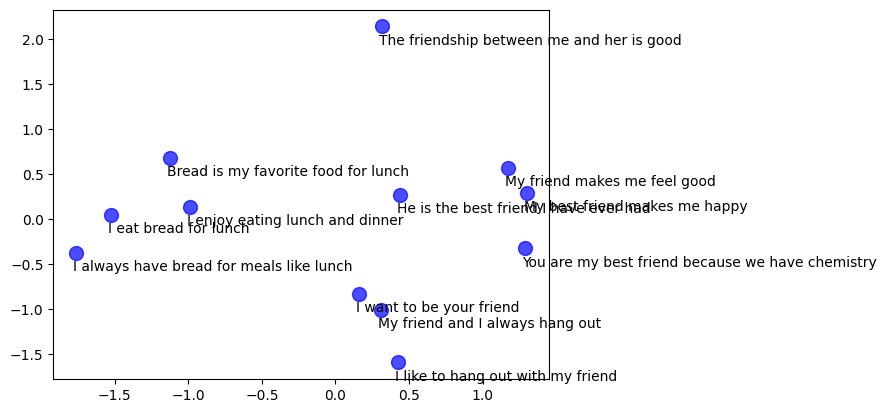

In [14]:
U, S, Vt = np.linalg.svd(Xc, full_matrices = False)
coords = U[:, :2] * S[:2]
print(coords)

plt.scatter(coords[:, 0], coords[:, 1], s = 100, c = 'blue', alpha = 0.7)
names = np.array([str(i + 1) for i in range(len(sentences))])
for i in range(len(sentences)):
    # pass
    plt.text(coords[:, 0][i] - 0.02, coords[:, 1][i] - 0.2, sentences[i], fontsize = 10)
plt.show()

**Nhận xét**
- Các câu chủ đề về "ăn trưa, bánh mì" và "bạn thân nằm gần nhau".
- Tuy nhiên, câu cụm từ "friendship" (tình bạn) cách khá xa so với những từ về "friend" còn lại.